In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('games.csv')

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
df['name'] = df['name'].fillna('unknown')

In [7]:
to_fill_as_int = ['year_of_release', 'critic_score']

In [8]:
for col in to_fill_as_int:
    df[col] = df[col].fillna(0)

    df[col] = df[col].astype('int')

    for index in range(len(df[col])):
        if df[col][index] == 0:
            df[col][index] = 'unknown'
    print(col)
    print(df[col].unique())
    print()

year_of_release
[2006 1985 2008 2009 1996 1989 1984 2005 1999 2007 2010 2013 2004 1990
 1988 2002 2001 2011 1998 2015 2012 2014 1992 1997 1993 1994 1982 2016
 2003 1986 2000 'unknown' 1995 1991 1981 1987 1980 1983]

critic_score
[76 'unknown' 82 80 89 58 87 91 61 97 95 77 88 83 94 93 85 86 98 96 90 84
 73 74 78 92 71 72 68 62 49 67 81 66 56 79 70 59 64 75 60 63 69 50 25 42
 44 55 48 57 29 47 65 54 20 53 37 38 33 52 30 32 43 45 51 40 46 39 34 35
 41 36 28 31 27 26 19 23 24 21 17 22 13]



In [9]:
df[col].unique()

array([76, 'unknown', 82, 80, 89, 58, 87, 91, 61, 97, 95, 77, 88, 83, 94,
       93, 85, 86, 98, 96, 90, 84, 73, 74, 78, 92, 71, 72, 68, 62, 49, 67,
       81, 66, 56, 79, 70, 59, 64, 75, 60, 63, 69, 50, 25, 42, 44, 55, 48,
       57, 29, 47, 65, 54, 20, 53, 37, 38, 33, 52, 30, 32, 43, 45, 51, 40,
       46, 39, 34, 35, 41, 36, 28, 31, 27, 26, 19, 23, 24, 21, 17, 22, 13],
      dtype=object)

In [10]:
df['genre'] = df['genre'].fillna('unknown')

In [11]:
df['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [12]:
df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [13]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [14]:
df['user_score'] = df['user_score'].fillna('unknown')

In [15]:
df['user_score'].unique()

array([8.0, 'unknown', 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9.0,
       7.9, 8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 7.5, 2.6,
       7.2, 9.2, 7.0, 7.3, 4.3, 7.6, 5.7, 5.0, 9.1, 6.5, 8.8, 6.9, 9.4,
       6.8, 6.1, 6.7, 5.4, 4.0, 4.9, 4.5, 9.3, 6.2, 4.2, 6.0, 3.7, 4.1,
       5.8, 5.6, 5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1,
       3.5, 2.5, 1.9, 3.0, 2.7, 2.2, 2.0, 9.5, 2.1, 3.6, 2.8, 1.8, 3.8,
       0.0, 1.6, 9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3,
       0.2, 0.6, 1.4, 0.9, 1.0, 9.7], dtype=object)

In [16]:
df['rating'] = df['rating'].fillna('unknown')

In [17]:
for index in range(len(df['rating'])):
    if df['rating'][index] in [0, 'RP']:
        df['rating'][index] = 'unknown'
    if df['rating'][index] in ['K-A', 'EC']:
        df['rating'][index] = 'E'

In [18]:
df['rating'].unique()

array(['E', 'unknown', 'M', 'T', 'E10+', 'AO'], dtype=object)

In [19]:
df.insert(8, 'total_sales', df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  object 
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   total_sales      16715 non-null  float64
 9   critic_score     16715 non-null  object 
 10  user_score       16715 non-null  object 
 11  rating           16715 non-null  object 
dtypes: float64(5), object(7)
memory usage: 1.5+ MB


In [21]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.54,76,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,40.24,unknown,unknown,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,31.38,unknown,unknown,unknown


In [22]:
pivot_by_year = df[df['year_of_release'] != 'unknown'].pivot_table(index='year_of_release', values='name', aggfunc='count')

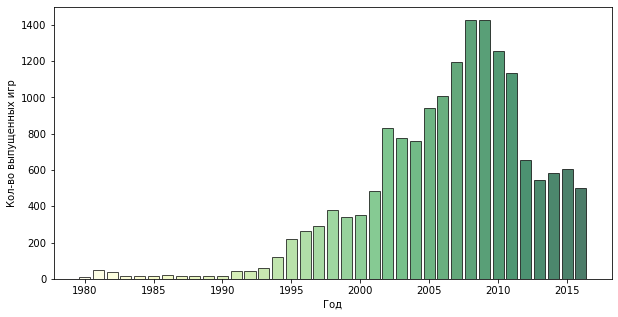

In [99]:
x=pivot_by_year.index
y=pivot_by_year['name']

plt.figure(figsize=(10,5))

plt.xlabel('Год')
plt.ylabel('Кол-во выпущенных игр')

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.bar(x, y, color=colors, edgecolor = "black", alpha=0.7)
plt.show()

In [76]:
pivot_by_platform = df.pivot_table(index='platform', 
                                   values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'], 
                                   aggfunc='sum').sort_values(by='total_sales', 
                                                                ascending=True).tail(10)

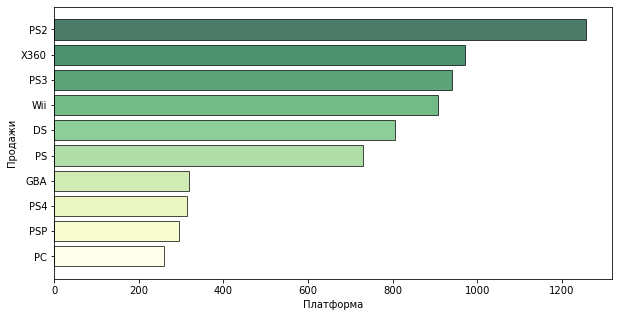

In [100]:
x=pivot_by_platform.index
y=pivot_by_platform['total_sales']

gradient = np.linspace(0, 1, 256)

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Продажи')

plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)

plt.show()

In [26]:
top_platforms = list(pivot_by_platform.index)
top_platform_sales = df.query('platform in @top_platforms & year_of_release != "unknown"')

In [27]:
each_platform_pivot_by_year = top_platform_sales.pivot_table(index='year_of_release', 
                                                             values='total_sales', 
                                                             columns = 'platform',
                                                             aggfunc='sum')

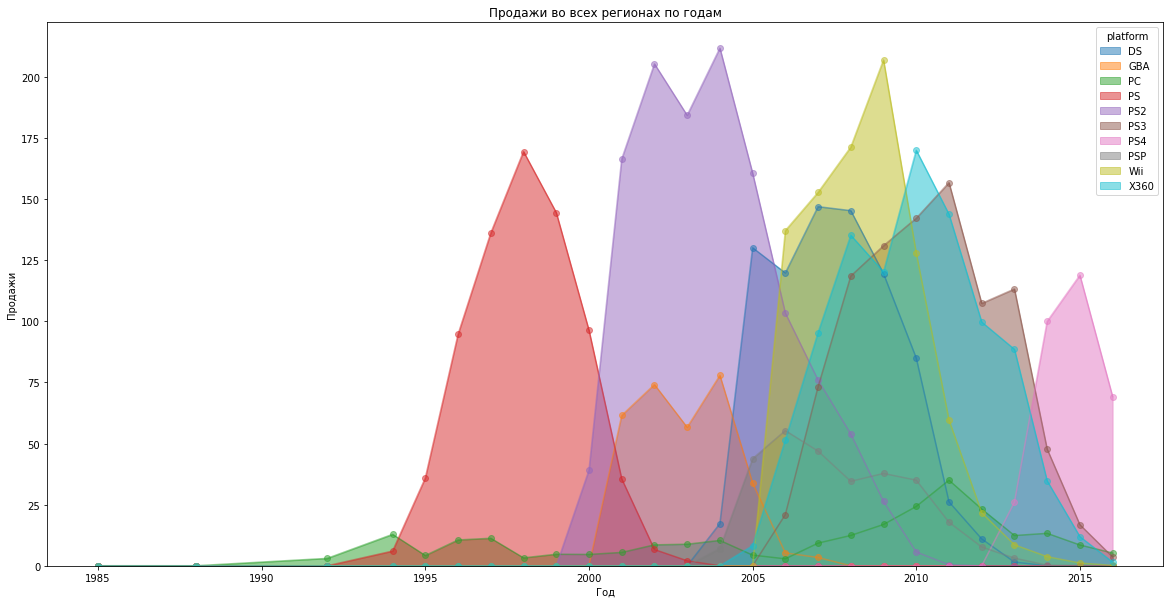

In [28]:
each_platform_pivot_by_year.plot.area(figsize=(20,10),
                                      xlabel = 'Год',
                                      ylabel = 'Продажи',
                                      title = 'Продажи во всех регионах по годам',
                                      style = 'o-',
                                      stacked=False);

In [29]:
each_platform_pivot_by_year_filled = each_platform_pivot_by_year.fillna(0)

In [30]:
def to_percentage (data):
    for col in data.columns:
        data[col] = (data[col] / data[col].sum())

In [31]:
each_platform_pivot_by_year_percentage_filled = each_platform_pivot_by_year_filled.copy()
to_percentage(each_platform_pivot_by_year_percentage_filled)

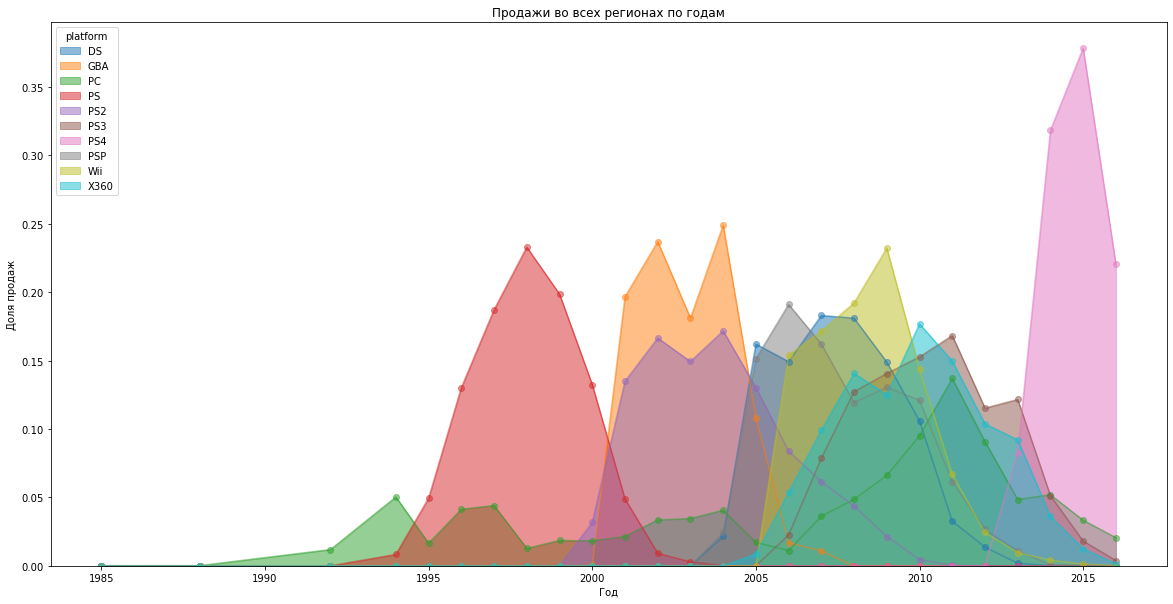

In [32]:
each_platform_pivot_by_year_percentage_filled.plot.area(figsize=(20,10),
                                      xlabel = 'Год',
                                      ylabel = 'Доля продаж',
                                      title = 'Продажи во всех регионах по годам',
                                      style = 'o-',
                                      stacked=False);

In [33]:
platform_lifetime = pd.DataFrame(index=['min_year', 'mean_year', 'max_year', 'lifetime'])

for platform in each_platform_pivot_by_year_percentage_filled.columns:
    mean_year = 0
    mean_year2 = 0

    for year in each_platform_pivot_by_year_percentage_filled.index:
        if each_platform_pivot_by_year_percentage_filled[platform][year] == None:
            print(1)
        mean_year += year * each_platform_pivot_by_year_percentage_filled[platform][year]
        mean_year2 += year * year * each_platform_pivot_by_year_percentage_filled[platform][year]
        
    mean2_year = mean_year ** 2
    var_year = mean_year2 - mean2_year
    std_year = np.sqrt(var_year)

    min_year = mean_year - 3*std_year
    max_year = mean_year + 3*std_year
    lifetime = max_year - min_year

    platform_lifetime[platform] = [min_year, mean_year, max_year, lifetime]

platform_lifetime = np.transpose(platform_lifetime)
platform_lifetime = platform_lifetime.sort_values(by='lifetime')

In [34]:
platform_lifetime.style.format('{:.2f}')

,min_year,mean_year,max_year,lifetime
PS4,2012.05,2014.74,2017.42,5.37
GBA,1998.66,2002.93,2007.20,8.54
PS,1993.13,1998.03,2002.93,9.81
Wii,2003.34,2008.42,2013.51,10.17
DS,2001.90,2007.47,2013.04,11.14
PSP,2001.30,2007.63,2013.96,12.67
PS3,2003.84,2010.36,2016.88,13.04
PS2,1997.12,2003.78,2010.44,13.32
X360,2003.19,2009.89,2016.58,13.39
PC,1987.12,2006.65,2026.18,39.06


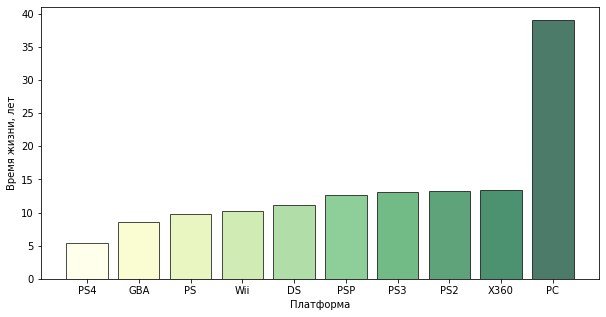

In [101]:
x=platform_lifetime.index
y=platform_lifetime['lifetime']

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Время жизни, лет')

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.bar(x, y, color=colors, edgecolor = "black", alpha=0.7)

plt.show()

In [36]:
mean_lifetime = round(platform_lifetime[platform_lifetime.index != 'PC']['lifetime'].mean(),2)
mean_lifetime

10.83

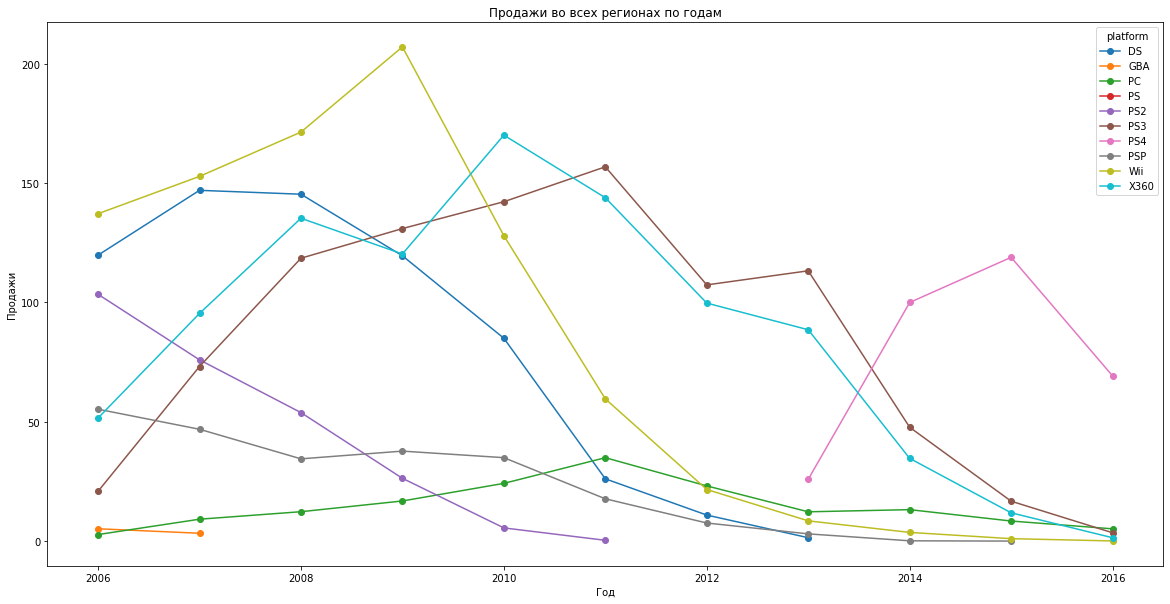

In [37]:
each_platform_pivot_by_year.query('year_of_release > (year_of_release.max()-@mean_lifetime)')\
.plot(figsize=(20,10),
      xlabel = 'Год',
      ylabel = 'Продажи',
      title = 'Продажи во всех регионах по годам',
      style = 'o-',
      stacked=False);

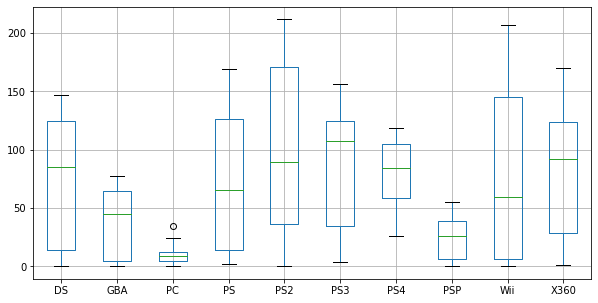

In [38]:
each_platform_pivot_by_year.boxplot(figsize = (10,5));

In [39]:
def drop_unknown (data):
    for col in data:
        data = data[data[col] != 'unknown']
    return data

In [40]:
def quantile_filter (data):

    before_filter = len(data.index)

    for col in data.columns:
        
        top_filter = data[col].quantile(.98)
        data = data[data[col] <= top_filter]
    
        bottom_filter = data[col].quantile(.01)
        data = data[data[col] >= bottom_filter]

    after_filter = len(data.index)

    data_loss = (before_filter - after_filter) / before_filter
    
    print(f'''Платформа: {platform}
Выбросы удалены, потеряно {data_loss:.1%} данных''')
    
    return data

In [41]:
def scatter_plot (data):

    x=data['total_sales']
    y=data['critic_score']

    plt.figure(figsize=(10,10))

    plt.xlabel('Продажи')
    plt.ylabel('Оценка критиков')
    plt.title(platform)

    plt.scatter(x, y, alpha=0.3)
    plt.show()

In [42]:
def unknown (data):
    for col in data:
        data = data[data[col] != 'unknown']

Платформа: PC
Выбросы удалены, потеряно 4.3% данных


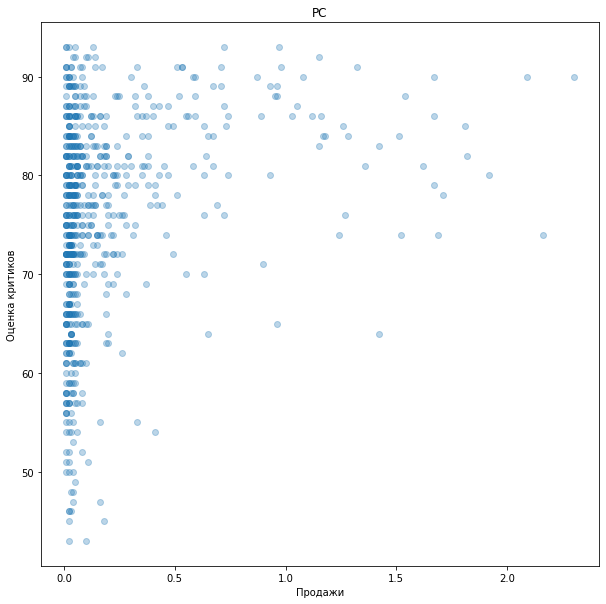

In [103]:
platform = 'PC'
score_by_sales = df.query('platform == @platform')[['total_sales', 'critic_score']]

score_by_sales = drop_unknown(score_by_sales)
score_by_sales['critic_score'] = score_by_sales['critic_score'].astype(int)
score_by_sales = quantile_filter(score_by_sales)

scatter_plot (score_by_sales)

In [44]:
platform_to_sales_corr = pd.DataFrame(index=top_platforms, columns=['corr'])

In [45]:
platform_to_sales_corr.loc['PC']['corr'] = score_by_sales.corr().loc['total_sales']['critic_score']

In [46]:
top_platforms.remove('PC')

Платформа: PSP
Выбросы удалены, потеряно 4.3% данных


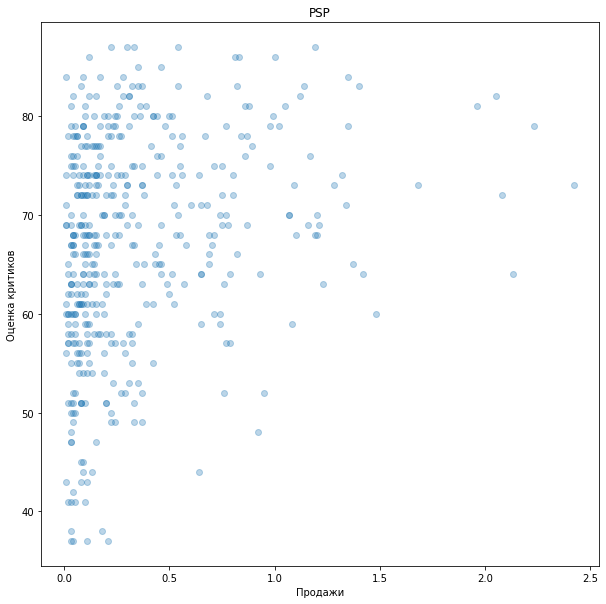

--------------------------------------------------------------------------------
Платформа: PS4
Выбросы удалены, потеряно 5.2% данных


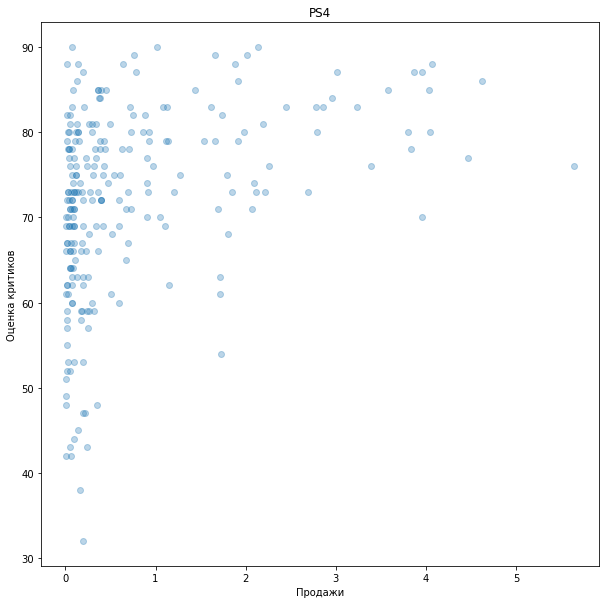

--------------------------------------------------------------------------------
Платформа: GBA
Выбросы удалены, потеряно 5.0% данных


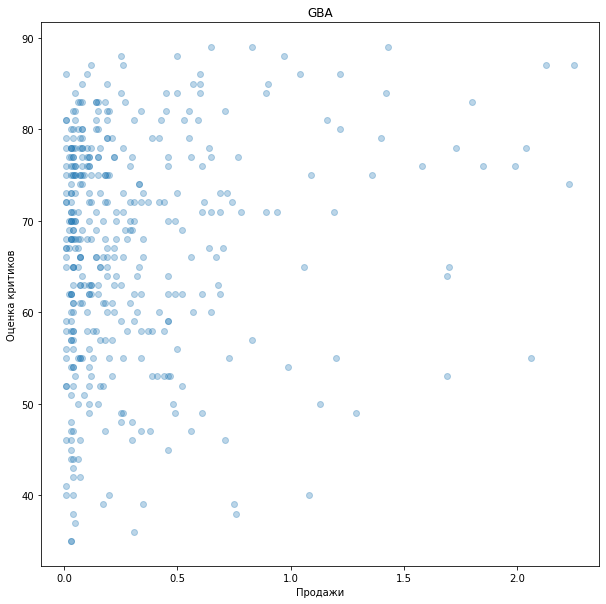

--------------------------------------------------------------------------------
Платформа: PS
Выбросы удалены, потеряно 4.0% данных


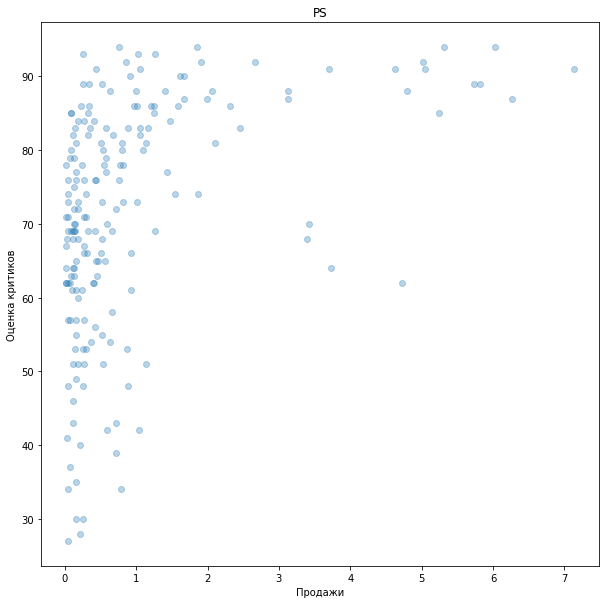

--------------------------------------------------------------------------------
Платформа: DS
Выбросы удалены, потеряно 4.6% данных


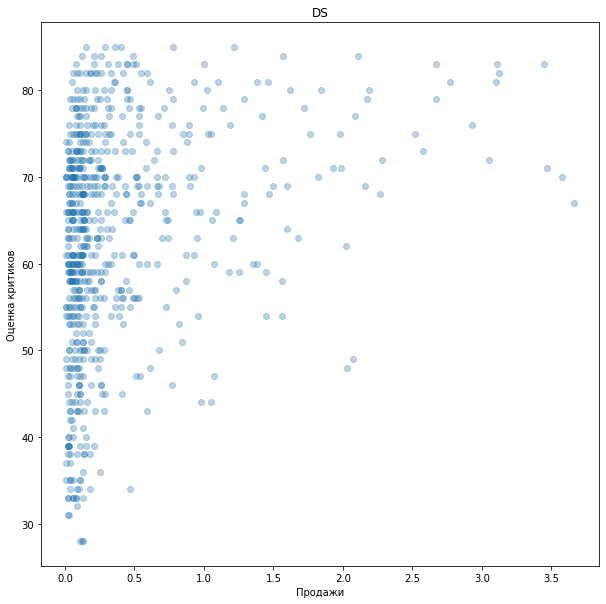

--------------------------------------------------------------------------------
Платформа: Wii
Выбросы удалены, потеряно 5.3% данных


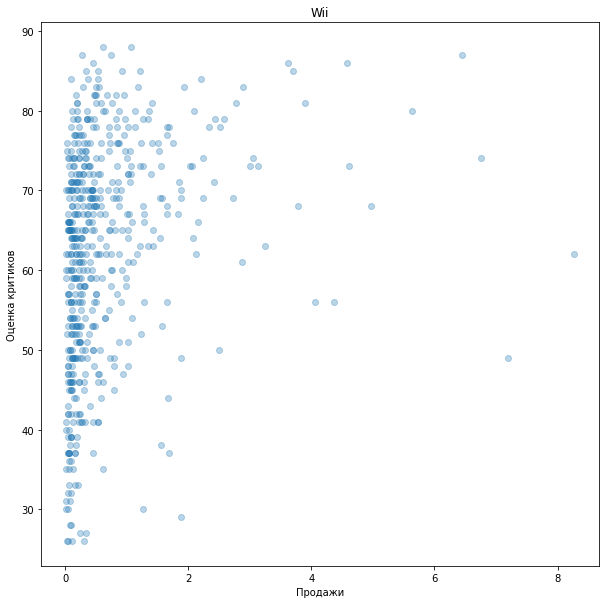

--------------------------------------------------------------------------------
Платформа: PS3
Выбросы удалены, потеряно 6.0% данных


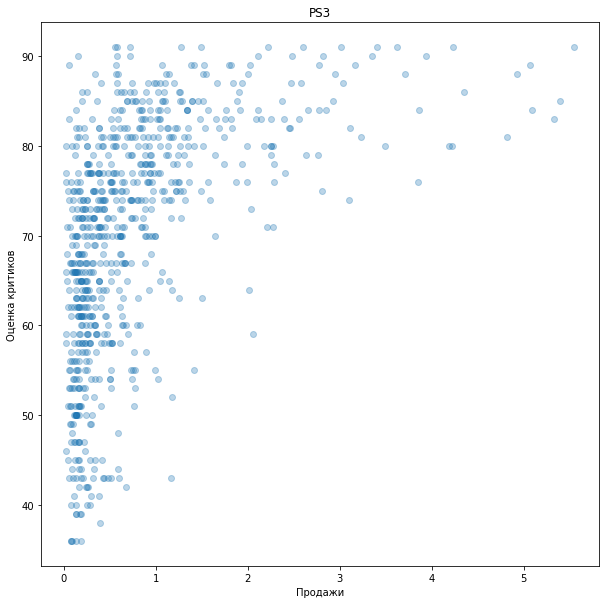

--------------------------------------------------------------------------------
Платформа: X360
Выбросы удалены, потеряно 5.8% данных


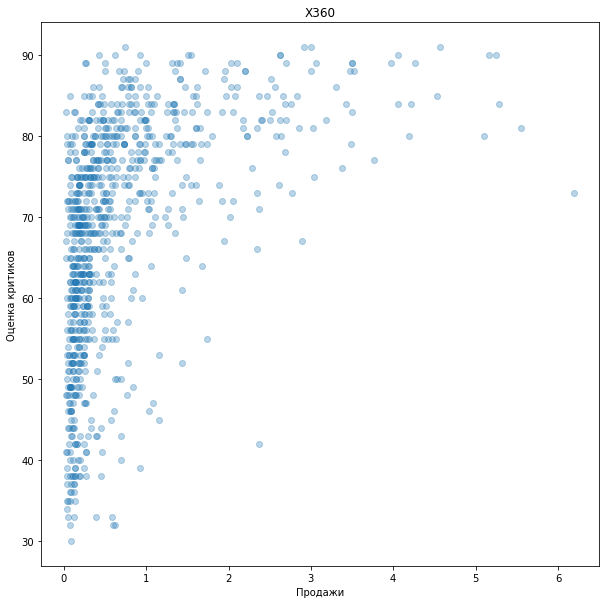

--------------------------------------------------------------------------------
Платформа: PS2
Выбросы удалены, потеряно 4.9% данных


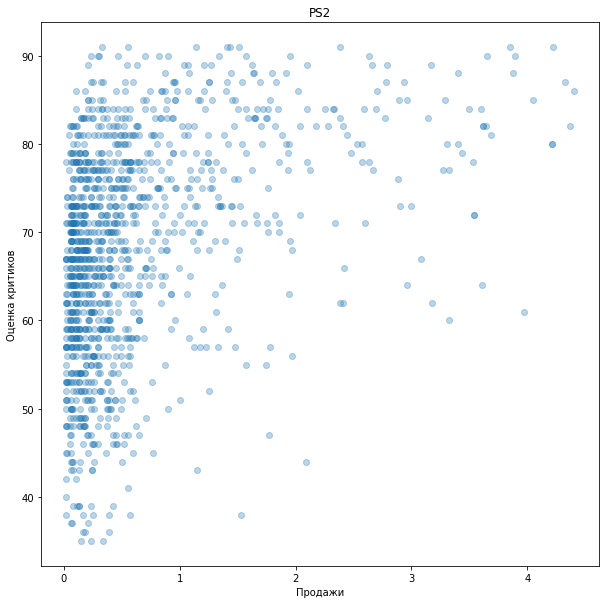

--------------------------------------------------------------------------------


In [47]:
for platform in top_platforms:
    score_by_sales = df.query('platform == @platform')\
                   .dropna(subset=['total_sales','critic_score'])[['total_sales', 'critic_score']]
    
    score_by_sales = drop_unknown(score_by_sales)
    score_by_sales = quantile_filter(score_by_sales)
    scatter_plot(score_by_sales)
    score_by_sales['critic_score'] = score_by_sales['critic_score'].astype(int)
    platform_to_sales_corr.loc[platform]['corr'] = score_by_sales.corr().loc['total_sales']['critic_score']
    print('--------------------------------------------------------------------------------')

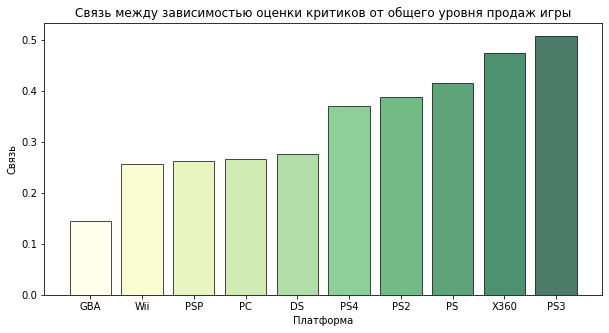

In [104]:
platform_to_sales_corr = platform_to_sales_corr.sort_values(by='corr')

x=platform_to_sales_corr.index
y=platform_to_sales_corr['corr']

plt.figure(figsize=(10,5))

plt.xlabel('Платформа')
plt.ylabel('Связь')
plt.title('Связь между зависимостью оценки критиков от общего уровня продаж игры')

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.bar(x, y, color=colors, edgecolor = "black", alpha=0.7)

plt.show()

In [106]:
pivot_by_genre = df.pivot_table(index='genre', 
                                values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'], 
                                aggfunc='sum').sort_values(by='total_sales')
pivot_by_genre = pivot_by_genre[pivot_by_genre.index != 'unknown']

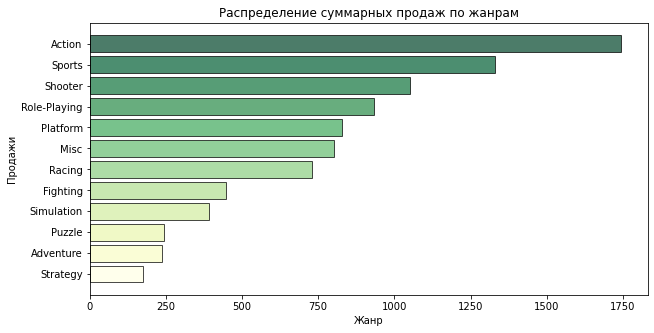

In [107]:
x=pivot_by_genre.index
y=pivot_by_genre['total_sales']

plt.figure(figsize=(10,5))

plt.xlabel('Жанр')
plt.ylabel('Продажи')
plt.title('Распределение суммарных продаж по жанрам')

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)

plt.show()

In [51]:
regions = list(pivot_by_platform.columns)
regions.remove('total_sales')

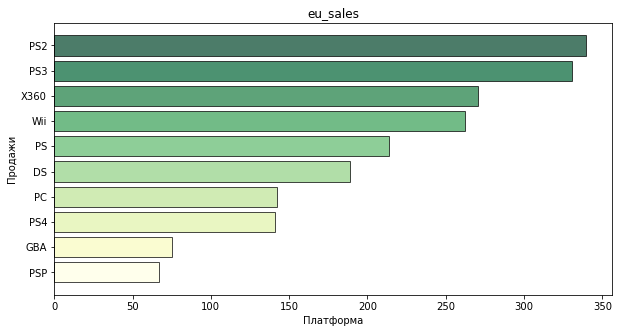

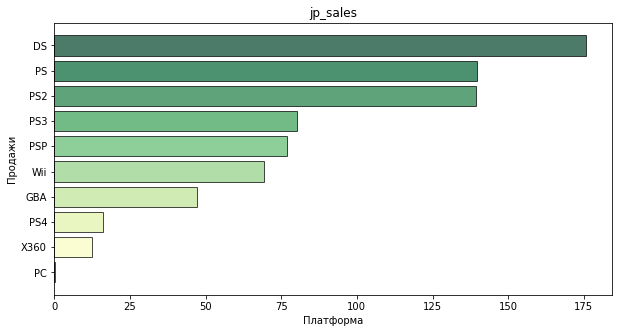

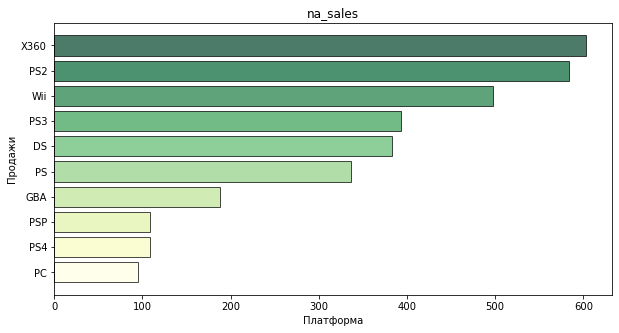

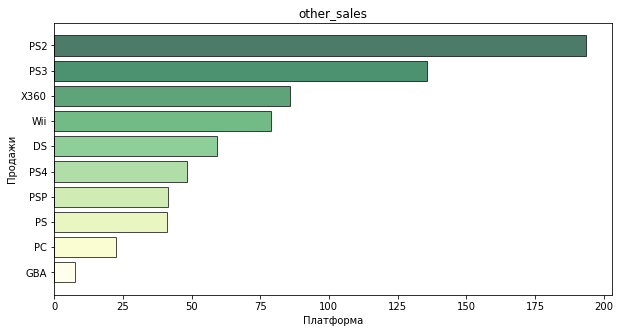

In [109]:
for region in regions:
    pivot_by_platform = pivot_by_platform.sort_values(by=region)
    x=pivot_by_platform.index
    y=pivot_by_platform[region]

    plt.figure(figsize=(10,5))

    plt.xlabel('Платформа')
    plt.ylabel('Продажи')
    plt.title(region)
    
    colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

    plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)

    plt.show()

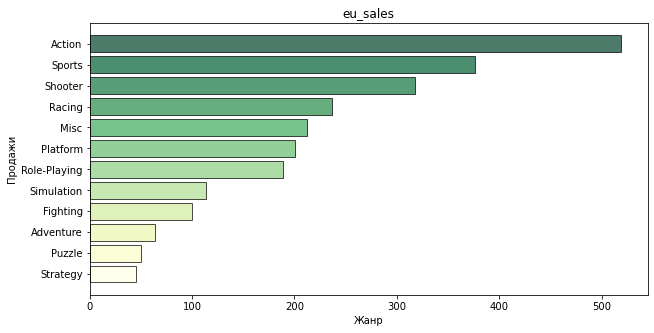

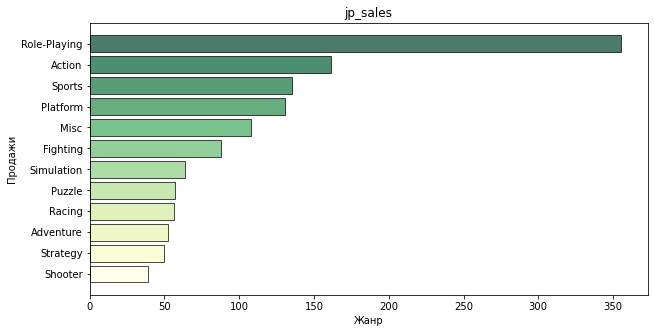

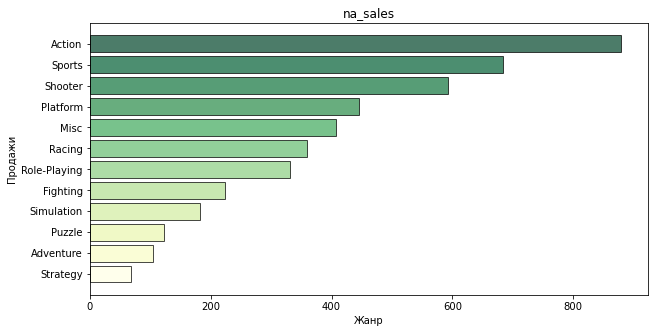

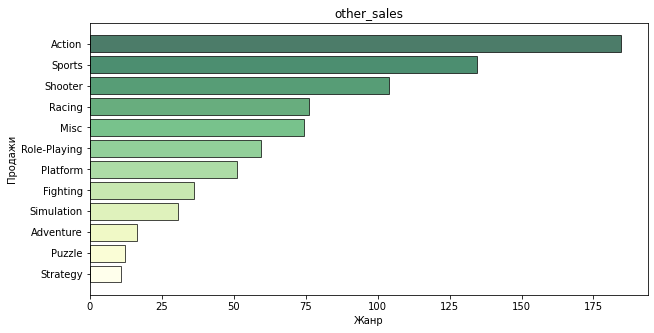

In [111]:
for region in regions:
    pivot_by_genre = pivot_by_genre.sort_values(by=region)
    pivot_by_genre = pivot_by_genre[pivot_by_genre.index != 'unknown']
    
    x=pivot_by_genre.index
    y=pivot_by_genre[region]

    plt.figure(figsize=(10,5))

    plt.xlabel('Жанр')
    plt.ylabel('Продажи')
    plt.title(region)

    colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

    plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)
    
    plt.show()

In [54]:
pivot_by_rating = df.pivot_table(index='rating', 
                                values=['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales'], 
                                aggfunc='sum')
pivot_by_rating = pivot_by_rating[pivot_by_rating.index != 'unknown']

In [55]:
pivot_by_rating

,eu_sales,jp_sales,na_sales,other_sales,total_sales
rating,,,,,
AO,0.61,0.00,1.26,0.09,1.96
E,710.63,199.57,1297.08,234.31,2441.59
E10+,188.52,40.20,353.32,73.56,655.60
M,483.97,64.24,748.48,177.10,1473.79
T,427.03,151.40,759.75,155.17,1493.35


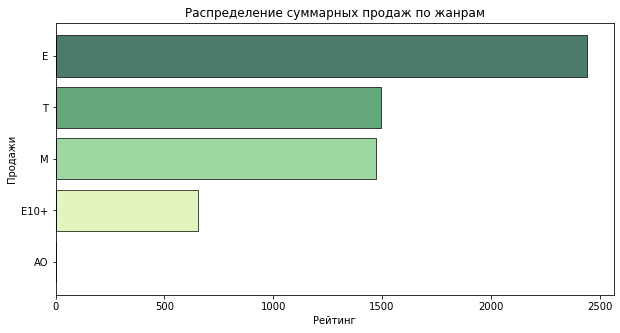

In [112]:
pivot_by_rating = pivot_by_rating.sort_values(by='total_sales')

x=pivot_by_rating.index
y=pivot_by_rating['total_sales']

plt.figure(figsize=(10,5))

plt.xlabel('Рейтинг')
plt.ylabel('Продажи')
plt.title('Распределение суммарных продаж по жанрам')

colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)

plt.show()

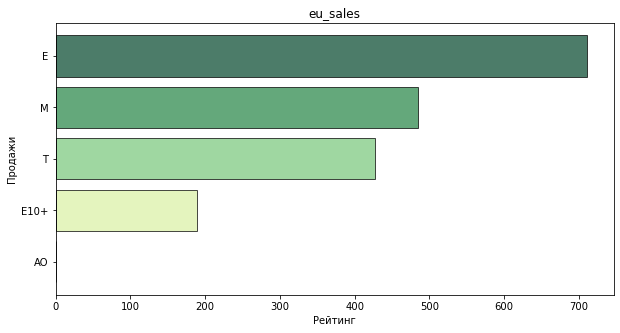

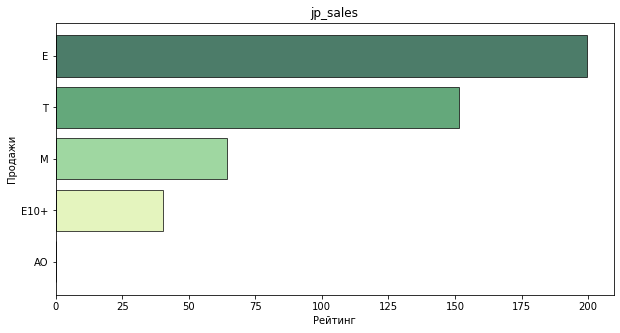

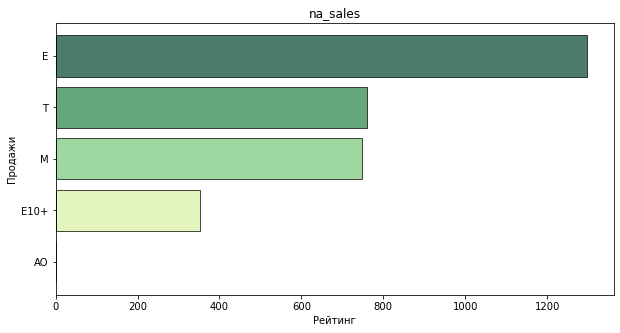

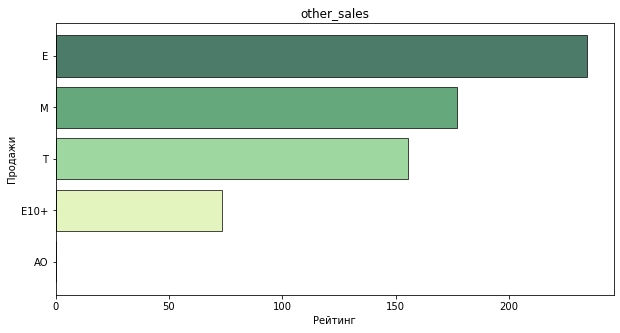

In [114]:
for region in regions:
    
    pivot_by_rating = pivot_by_rating.sort_values(by=region)
    
    pivot_by_rating = pivot_by_rating.sort_values(by=region)
    x=pivot_by_rating.index
    y=pivot_by_rating[region]

    plt.figure(figsize=(10,5))

    plt.xlabel('Рейтинг')
    plt.ylabel('Продажи')
    plt.title(region)
    
    colors = plt.cm.YlGn(np.linspace(0, 1, len(x)))

    plt.barh(x, y, color=colors, edgecolor = "black", alpha=0.7)

    plt.show()

In [58]:
xone_vs_pc = df.query('platform in ["XOne","PC"]')[['platform','user_score']]
xone_vs_pc = drop_unknown(xone_vs_pc)
xone_vs_pc = xone_vs_pc.sort_values(by='user_score')
xone_vs_pc['user_score'] = xone_vs_pc['user_score'].astype(float)

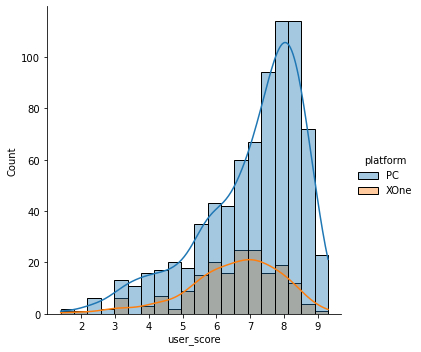

In [59]:
sns.displot(xone_vs_pc, x="user_score", hue="platform", alpha=0.4, kde=True);

In [60]:
describe_xone_vs_pc = xone_vs_pc.pivot_table(index='platform', aggfunc=['count', 'mean', 'median'])\
.style.format('{:.2}', subset=['mean', 'median'])

In [61]:
describe_xone_vs_pc

,count,mean,median
,user_score,user_score,user_score
platform,,,
PC,770,7.1,7.5
XOne,182,6.5,6.8


In [62]:
xone = xone_vs_pc.query('platform == "XOne"')['user_score']
pc = xone_vs_pc.query('platform == "PC"')['user_score']

alpha = .05 

results = st.ttest_ind(xone, pc, equal_var = False)

print(f'p-значение: {results.pvalue :.5%}')

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 0.00049%
Отвергаем нулевую гипотезу


In [63]:
df['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', 'unknown'], dtype=object)

In [64]:
action_vs_sports = df.query('genre in ["Action","Sports"]')[['genre','user_score']]
action_vs_sports = drop_unknown(action_vs_sports)
action_vs_sports = action_vs_sports.sort_values(by='user_score')
action_vs_sports['user_score'] = action_vs_sports['user_score'].astype(float)

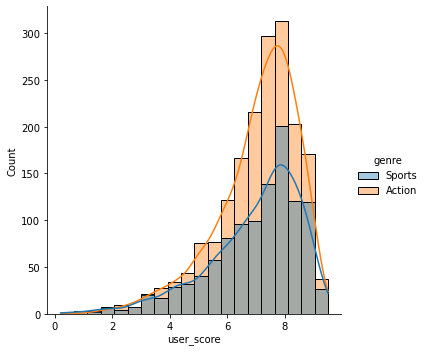

In [65]:
sns.displot(action_vs_sports, bins=20, x="user_score", hue="genre", alpha=0.4, kde=True);

In [66]:
describe_action_vs_sports = action_vs_sports.pivot_table(index='genre', aggfunc=['count', 'mean', 'median'])\
.style.format('{:.2}', subset=['mean', 'median'])

In [67]:
describe_action_vs_sports

,count,mean,median
,user_score,user_score,user_score
genre,,,
Action,1830,7.1,7.4
Sports,1103,7.0,7.4


In [68]:
action = action_vs_sports.query('genre == "Action"')['user_score']
sports = action_vs_sports.query('genre == "Sports"')['user_score']

alpha = .05 

results = st.ttest_ind(action, sports, equal_var = False)

print(f'p-значение: {results.pvalue :.2%}')

if results.pvalue > alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 11.48%
Отвергаем нулевую гипотезу
